# Low-level Evaluation on Augmented Data

## This is Part 4.2. in the official paper, image synthesis method: ArtStyle

We use the PyTorch implementation of ArtStyle: https://pytorch.org/tutorials/advanced/neural_style_tutorial.html

It uses VGG19 (trained on ImageNet) for feature extraction.

We did experiments on 4 domains:
1. Chocolate cake <-> Vanilla cake
2. Zebra <-> Horse
3. Orange <-> Apple
4. Milk <-> Bubble Milk

Images were initially resized to 288x288 and stored in 'images' folder. It contains folders 'trainA' - for content images and 'trainB' - for style images.

In [ ]:
%matplotlib inline

In [1]:
!pip install torchmetrics clean-fid
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time

from PIL import Image
import matplotlib.pyplot as plt

from cleanfid import fid
import numpy as np

import lpips
import os
import sys
import random


import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import copy

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

In [4]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

IN_COLAB

True

In [5]:
# Set project path based on the environment
if IN_COLAB:
    from google.colab import drive
    if not os.path.exists("/content/drive/My Drive"):
      drive.mount('/content/drive')
    else:
      print("Drive already mounted")

    project_path = "/content/drive/My Drive/4.2. ArtStyle/"


else:  # Assume local execution
    project_path = "../"

Mounted at /content/drive


## Defining metrics:

*   Fréchet Inception Distance (FID)

*   Learned Perceptual Image Patch Similarity (LPIPS)

*   VGG Loss (perceptual loss)


In [ ]:
def calculate_fid(image1_path: str, image2_path: str) -> float:
    # image1_path: Path to generated image directory
    # image2_path: Path to target style image directory

    fid_value = fid.compute_fid(image1_path, image2_path)
    return fid_value


lpips_loss = lpips.LPIPS(net='vgg').to('cpu')

def calculate_lpips(image1_path: str, image2_path: str) -> float:
    transform = transforms.ToTensor()

    # Load images and preprocess
    img1 = transform(Image.open(image1_path)).unsqueeze(0)
    img2 = transform(Image.open(image2_path)).unsqueeze(0)

    with torch.no_grad():
        distance = lpips_loss(img1, img2)

    return distance.item()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 163MB/s]


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/vgg.pth


In [6]:
vgg_model = vgg19(pretrained=True).features[:8].eval().to(device)
loss_fn = torch.nn.MSELoss()

def load_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((288, 288)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0).to(device)

def calculate_vgg_loss(real_image, generated_image):
    img1 = load_image(real_image)
    img2 = load_image(generated_image)
    with torch.no_grad():
        f1 = vgg_model(img1)
        f2 = vgg_model(img2)
        return loss_fn(f1, f2).item()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:07<00:00, 80.7MB/s]


# Experiment 1: Vanilla cake <-> Chocolate cake

We use single source and target image.

In [ ]:
loader = transforms.Compose([
    transforms.ToTensor()])  # transform image into a torch tensor


def image_loader(image_name):
    image = Image.open(image_name)
    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)


style_img = image_loader(project_path + "images/trainB/ChocolateCake.jpg")
content_img = image_loader(project_path + "images/trainA/VanillaCake.jpg")

assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

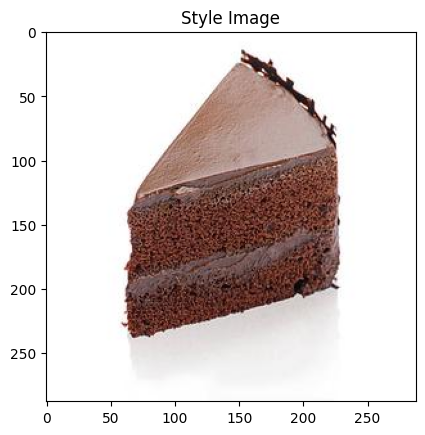

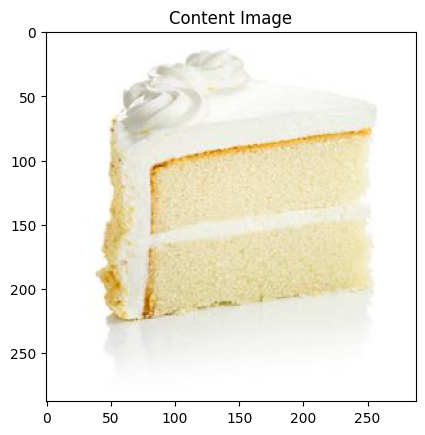

In [ ]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated


plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

In [ ]:
class ContentLoss(nn.Module):

    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input


def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resize F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)

class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

In [ ]:
cnn = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()

In [ ]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406])
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225])

# create a module to normalize input image so we can easily put it in a
# ``nn.Sequential``
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize ``img``
        return (img - self.mean) / self.std

# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std)

    # just in order to have an iterable access to or list of content/style
    # losses
    content_losses = []
    style_losses = []

    # assuming that ``cnn`` is a ``nn.Sequential``, so we make a new ``nn.Sequential``
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)

    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ``ContentLoss``
            # and ``StyleLoss`` we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

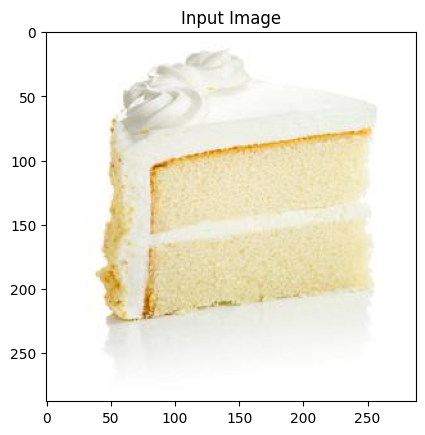

In [ ]:
input_img = content_img.clone()
plt.figure()
imshow(input_img, title='Input Image')

In [ ]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer


def run_style_transfer(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=1000,
                       style_weight=10000, content_weight=2):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_img, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    # We also put the model in evaluation mode, so that specific layers
    # such as dropout or batch normalization layers behave correctly.
    model.eval()
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]

    start_time = time.time()

    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    end_time = time.time()
    training_time = end_time - start_time
    print(f"\n Training Time: {training_time:.2f} seconds")

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 5.218058 Content Loss: 7.323924

run [100]:
Style Loss : 3.283253 Content Loss: 5.472417

run [150]:
Style Loss : 2.283771 Content Loss: 4.769372

run [200]:
Style Loss : 1.649853 Content Loss: 4.539520

run [250]:
Style Loss : 3.196466 Content Loss: 6.360695

run [300]:
Style Loss : 2.511038 Content Loss: 5.878438

run [350]:
Style Loss : 48.728561 Content Loss: 14.948832

run [400]:
Style Loss : 2.123649 Content Loss: 5.234928


 Training Time: 11.34 seconds


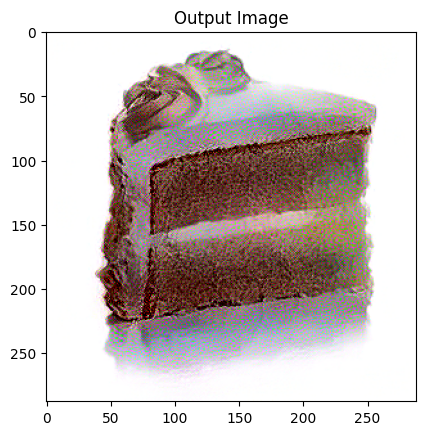

In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=400,
                       style_weight=10000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()


In [ ]:
output_dir = project_path + "results"
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Convert the output tensor to a PIL Image
output_image = transforms.ToPILImage()(output.squeeze().cpu())

# Define the output file path
output_file_path = os.path.join(output_dir, 'VanillaCake->ChocolateCake.jpg')

# Save the image to the specified directory
output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")


Image saved to /content/drive/My Drive/4.2. ArtStyle/results/VanillaCake->ChocolateCake.jpg


In [ ]:
lpips_value = calculate_lpips(project_path + "results/VanillaCake->ChocolateCake.jpg", project_path + "images/trainB/ChocolateCake.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.42195236682891846


In [7]:
vgg_value = calculate_vgg_loss(project_path + "images/trainA/VanillaCake.jpg", project_path + "results/VanillaCake->ChocolateCake.jpg")
print(f"VGG Loss: {vgg_value}")

VGG Loss: 12.148798942565918


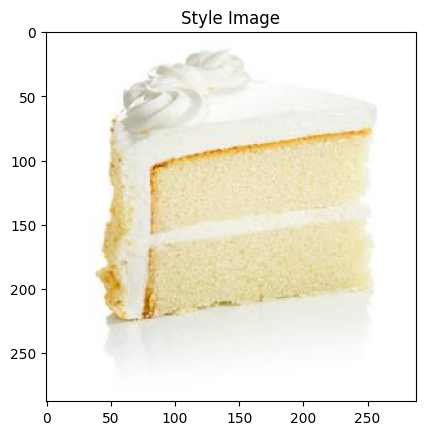

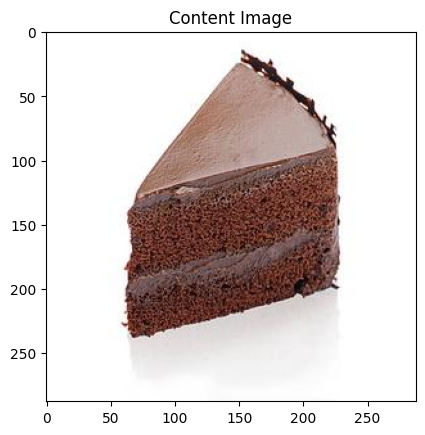

In [ ]:
style_img = image_loader(project_path + "images/trainA/VanillaCake.jpg")
content_img = image_loader(project_path + "images/trainB/ChocolateCake.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()



Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 4.498715 Content Loss: 5.659850

run [100]:
Style Loss : 2.883588 Content Loss: 6.133126

run [150]:
Style Loss : 1.761033 Content Loss: 5.810383

run [200]:
Style Loss : 1.320219 Content Loss: 5.493466

run [250]:
Style Loss : 1.469233 Content Loss: 5.684109

run [300]:
Style Loss : 0.951098 Content Loss: 4.965866

run [350]:
Style Loss : 22.186968 Content Loss: 8.479899

run [400]:
Style Loss : 1.599542 Content Loss: 5.950466


 Training Time: 11.63 seconds


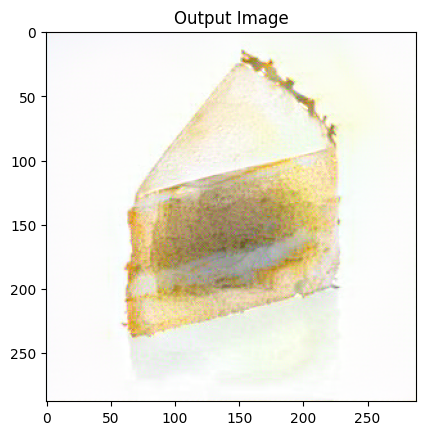

In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=400,
                       style_weight=100000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()


In [ ]:
output_dir = project_path + "results"
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Convert the output tensor to a PIL Image
output_image = transforms.ToPILImage()(output.squeeze().cpu())

# Define the output file path
output_file_path = os.path.join(output_dir, 'ChocolateCake->VanillaCake.jpg')

# Save the image to the specified directory
output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")


Image saved to /content/drive/My Drive/4.2. ArtStyle/results/ChocolateCake->VanillaCake.jpg


In [ ]:
lpips_value = calculate_lpips(project_path + "results/ChocolateCake->VanillaCake.jpg", project_path + "images/trainA/VanillaCake.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.3655579686164856


In [8]:
vgg_value = calculate_vgg_loss(project_path + "images/trainB/ChocolateCake.jpg", project_path + "results/ChocolateCake->VanillaCake.jpg")
print(f"VGG Loss: {vgg_value}")

VGG Loss: 6.941819190979004



# Experiment 2: Orange <-> Apple

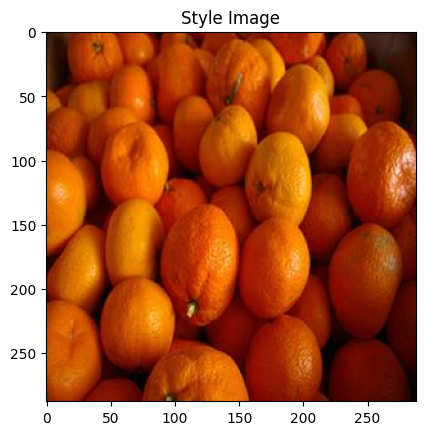

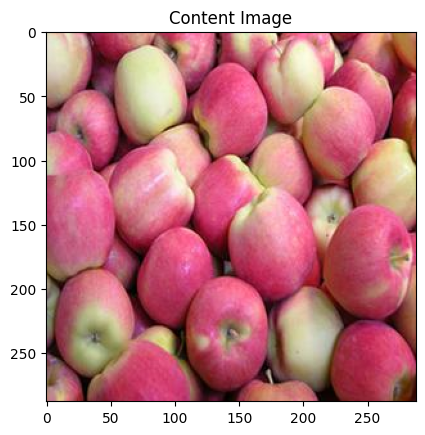

In [ ]:
style_img = image_loader(project_path + "images/trainB/Orange.jpg")
content_img = image_loader(project_path + "images/trainA/Apple.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 31.389837 Content Loss: 17.873693

run [100]:
Style Loss : 10.177834 Content Loss: 10.663402

run [150]:
Style Loss : 6.580027 Content Loss: 11.726578

run [200]:
Style Loss : 9.224948 Content Loss: 14.974981

run [250]:
Style Loss : 5.836936 Content Loss: 13.271350

run [300]:
Style Loss : 2.426842 Content Loss: 9.768050

run [350]:
Style Loss : 1.499541 Content Loss: 7.726424

run [400]:
Style Loss : 1.288057 Content Loss: 7.153792


 Training Time: 11.96 seconds


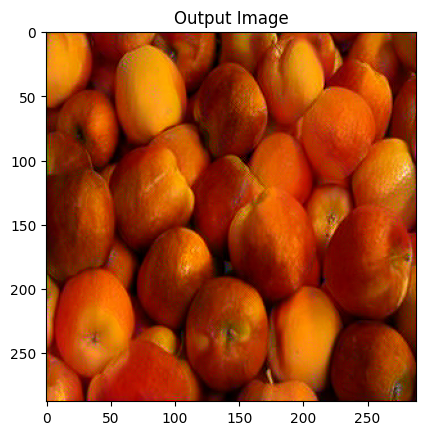

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/Apple->Orange.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=400,
                       style_weight=100000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()


output_image = transforms.ToPILImage()(output.squeeze().cpu())

output_file_path = os.path.join(output_dir, 'Apple->Orange.jpg')

output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")

In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainB/Orange.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.6108638644218445


In [10]:
vgg_value = calculate_vgg_loss(project_path + "images/trainA/Apple.jpg", project_path + 'results/Apple->Orange.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 8.824325561523438


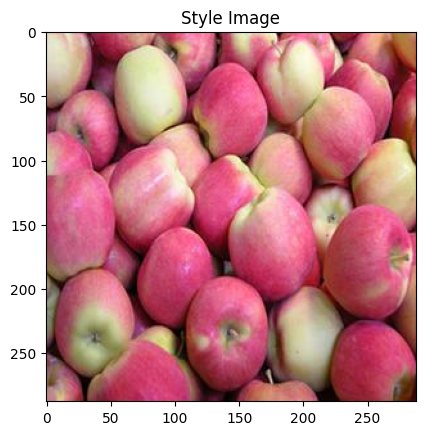

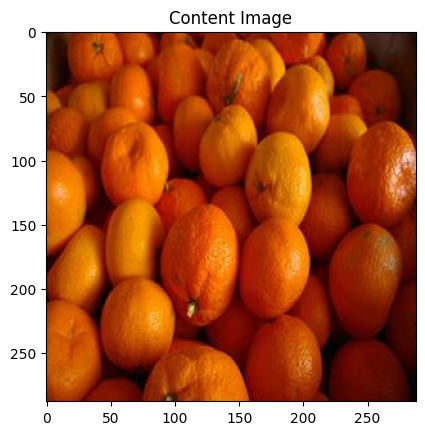

In [ ]:
style_img = image_loader(project_path + "images/trainA/Apple.jpg")
content_img = image_loader(project_path + "images/trainB/Orange.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()



Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 0.688011 Content Loss: 5.030024

run [100]:
Style Loss : 0.688192 Content Loss: 4.973938

run [150]:
Style Loss : 0.712147 Content Loss: 5.028265

run [200]:
Style Loss : 0.960782 Content Loss: 5.223443

run [250]:
Style Loss : 0.669701 Content Loss: 5.142920

run [300]:
Style Loss : 0.799237 Content Loss: 5.136395

run [350]:
Style Loss : 0.877976 Content Loss: 5.376163

run [400]:
Style Loss : 0.782500 Content Loss: 5.369438


 Training Time: 11.27 seconds


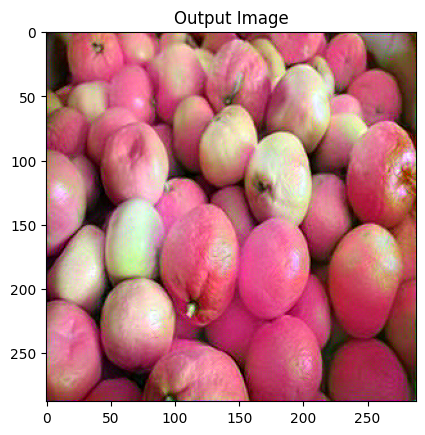

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/Orange->Apple.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=400,
                       style_weight=100000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()


# Convert the output tensor to a PIL Image
output_image = transforms.ToPILImage()(output.squeeze().cpu())

# Define the output file path
output_file_path = os.path.join(output_dir, 'Orange->Apple.jpg')

# Save the image to the specified directory
output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")


In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainA/Apple.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.5930424928665161


In [11]:
vgg_value = calculate_vgg_loss(project_path + "images/trainB/Orange.jpg", project_path + 'results/Orange->Apple.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 7.8552165031433105


# Experiment 3: Zebra <-> Horse

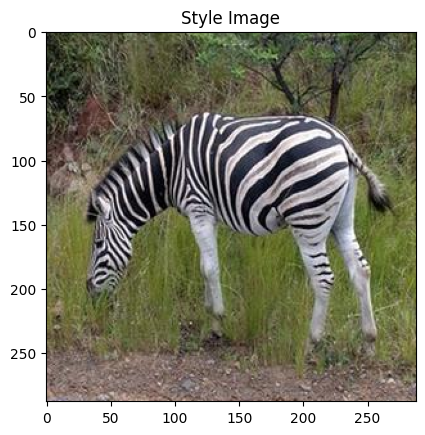

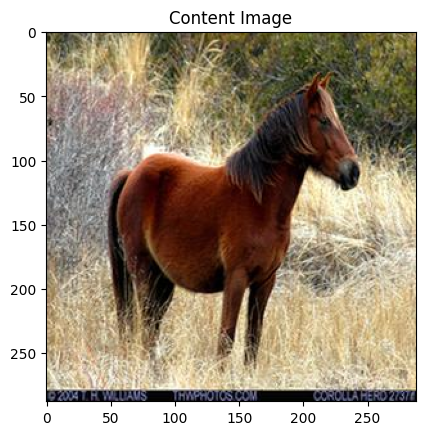

In [ ]:
style_img = image_loader(project_path + "images/trainB/Zebra.jpg")
content_img = image_loader(project_path + "images/trainA/Horse.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"
style_img = transforms.functional.hflip(style_img)
plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 0.922983 Content Loss: 9.263567

run [100]:
Style Loss : 1.103182 Content Loss: 8.579409

run [150]:
Style Loss : 1.208711 Content Loss: 8.170690

run [200]:
Style Loss : 1.249167 Content Loss: 7.837490

run [250]:
Style Loss : 1.241132 Content Loss: 7.628285

run [300]:
Style Loss : 1.245532 Content Loss: 7.409424


 Training Time: 8.99 seconds


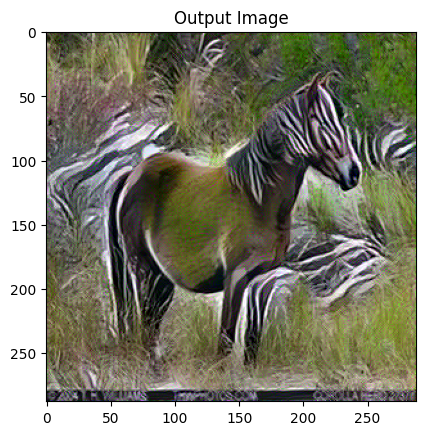

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/Horse->Zebra.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=300,
                       style_weight=100000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()


output_image = transforms.ToPILImage()(output.squeeze().cpu())

output_file_path = os.path.join(output_dir, 'Horse->Zebra.jpg')

output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")

In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainB/Zebra.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.610019326210022


In [12]:
vgg_value = calculate_vgg_loss(project_path + "images/trainA/Horse.jpg", project_path + 'results/Horse->Zebra.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 10.496337890625


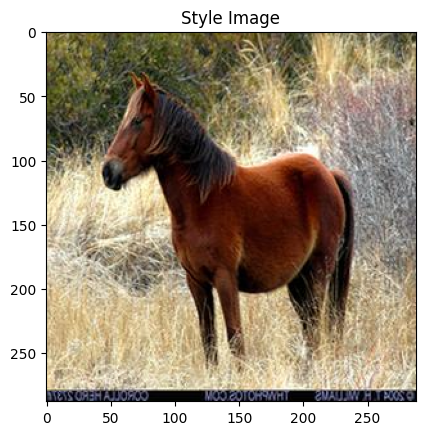

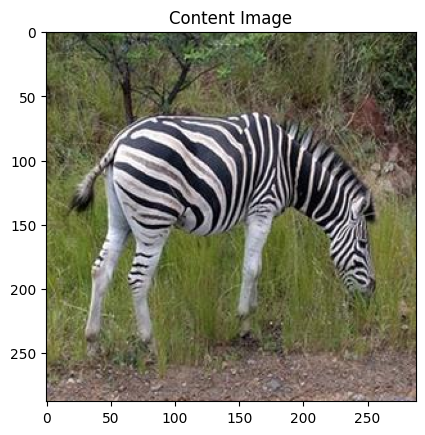

In [ ]:
style_img = image_loader(project_path + "images/trainA/Horse.jpg")
content_img = image_loader(project_path + "images/trainB/Zebra.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"
style_img = transforms.functional.hflip(style_img)
plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 3.246755 Content Loss: 8.531878

run [100]:
Style Loss : 2.117957 Content Loss: 8.607815

run [150]:
Style Loss : 1.531775 Content Loss: 8.660158

run [200]:
Style Loss : 1.281574 Content Loss: 8.690135

run [250]:
Style Loss : 1.503937 Content Loss: 8.580093

run [300]:
Style Loss : 1.157354 Content Loss: 8.387898


 Training Time: 8.89 seconds


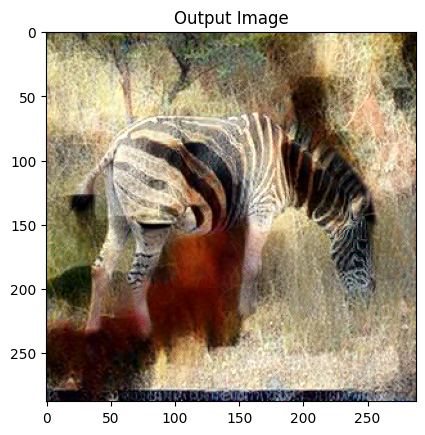

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/Zebra->Horse.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()

output_image = transforms.ToPILImage()(output.squeeze().cpu())

output_file_path = os.path.join(output_dir, 'Zebra->Horse.jpg')

output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")

In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainA/Horse.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.6035435795783997


In [13]:
vgg_value = calculate_vgg_loss(project_path + "images/trainB/Zebra.jpg", project_path + 'results/Zebra->Horse.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 12.065858840942383


# Experiment 4: Milk <-> Bubble milk

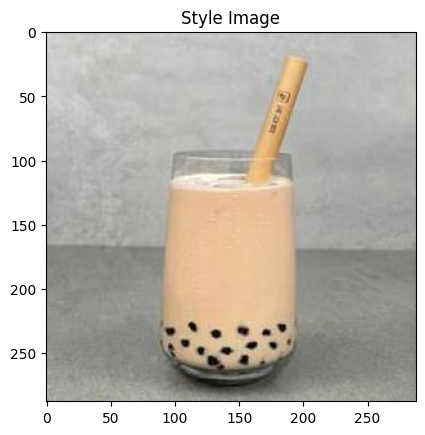

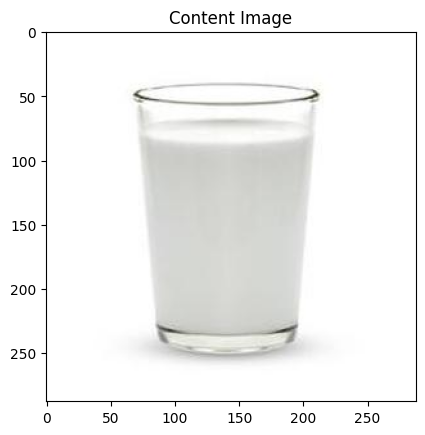

In [ ]:
style_img = image_loader(project_path + "images/trainB/BubbleMilk.jpg")
content_img = image_loader(project_path + "images/trainA/Milk.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"
style_img = transforms.functional.hflip(style_img)
plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 30.285578 Content Loss: 7.403031

run [100]:
Style Loss : 4.407736 Content Loss: 6.629369

run [150]:
Style Loss : 2.943668 Content Loss: 5.971950

run [200]:
Style Loss : 1.982916 Content Loss: 5.519894

run [250]:
Style Loss : 1.473143 Content Loss: 5.254997

run [300]:
Style Loss : 1.184132 Content Loss: 5.060992


 Training Time: 9.09 seconds


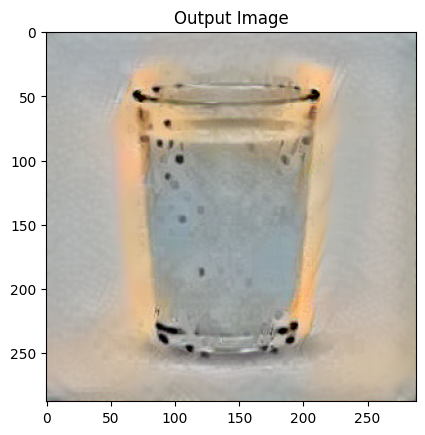

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/Milk->BubbleMilk.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=300,
                       style_weight=1000000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()

output_image = transforms.ToPILImage()(output.squeeze().cpu())

output_file_path = os.path.join(output_dir, 'Milk->BubbleMilk.jpg')

output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")

In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainB/BubbleMilk.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.5496609807014465


In [14]:
vgg_value = calculate_vgg_loss(project_path + "images/trainA/Milk.jpg", project_path + 'results/Milk->BubbleMilk.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 5.413027286529541


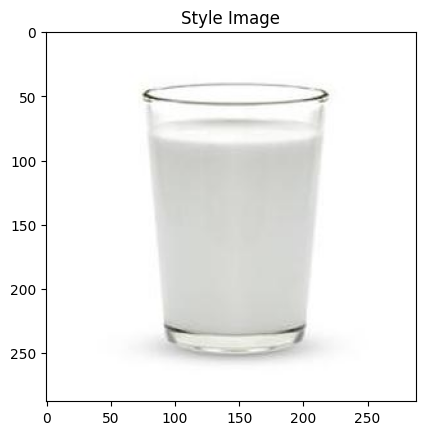

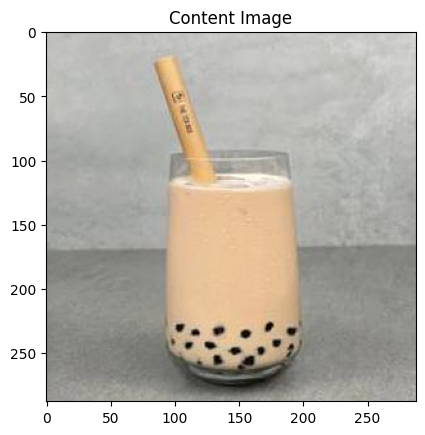

In [ ]:
style_img = image_loader(project_path + "images/trainA/Milk.jpg")
content_img = image_loader(project_path + "images/trainB/BubbleMilk.jpg")
assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"
style_img = transforms.functional.hflip(style_img)
plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

input_img = content_img.clone()

Building the style transfer model..
Optimizing..
run [50]:
Style Loss : 1.362272 Content Loss: 5.257254

run [100]:
Style Loss : 1.092570 Content Loss: 5.140553

run [150]:
Style Loss : 1.047637 Content Loss: 5.105904

run [200]:
Style Loss : 1.029135 Content Loss: 5.041392

run [250]:
Style Loss : 1.315480 Content Loss: 5.109913

run [300]:
Style Loss : 1.376739 Content Loss: 5.015971

run [350]:
Style Loss : 1.248782 Content Loss: 5.003958

run [400]:
Style Loss : 1.341193 Content Loss: 5.038672

run [450]:
Style Loss : 2.577252 Content Loss: 5.145421

run [500]:
Style Loss : 2.371242 Content Loss: 5.373402

run [550]:
Style Loss : 1.935187 Content Loss: 5.325197

run [600]:
Style Loss : 1.719170 Content Loss: 5.272272


 Training Time: 17.25 seconds


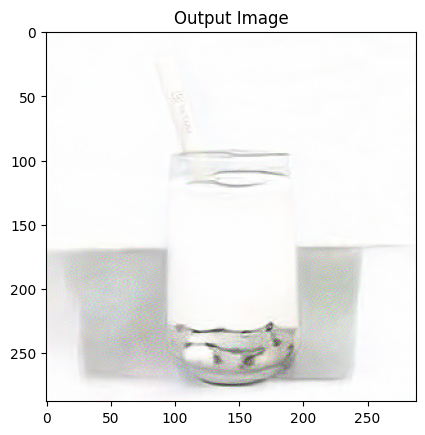

Image saved to /content/drive/My Drive/4.2. ArtStyle/results/BubbleMilk->Milk.jpg


In [ ]:
output = run_style_transfer(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img, num_steps=600,
                       style_weight=1000000, content_weight=1)

plt.figure()
imshow(output, title='Output Image')

plt.ioff()
plt.show()

output_image = transforms.ToPILImage()(output.squeeze().cpu())

output_file_path = os.path.join(output_dir, 'BubbleMilk->Milk.jpg')

output_image.save(output_file_path)
print(f"Image saved to {output_file_path}")

In [ ]:
lpips_value = calculate_lpips(output_file_path, project_path + "images/trainA/Milk.jpg")
print(f"LPIPS Score: {lpips_value}")


LPIPS Score: 0.3216375708580017


In [15]:
vgg_value = calculate_vgg_loss(project_path + "images/trainB/BubbleMilk.jpg", project_path + 'results/BubbleMilk->Milk.jpg')
print(f"VGG Loss: {vgg_value}")

VGG Loss: 6.128329277038574


In [ ]:
fid_value = calculate_fid(project_path + "results", project_path + "images/trainB")
print(f"FID Score: {fid_value}")

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


compute FID between two folders
Found 8 images in the folder /content/drive/My Drive/4.2. ArtStyle/results


FID results : 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


Found 4 images in the folder /content/drive/My Drive/4.2. ArtStyle/images/trainB


FID trainB : 100%|██████████| 1/1 [00:05<00:00,  5.16s/it]


FID Score: 237.98577847821318
